<a href="https://colab.research.google.com/github/syedahijabzahra/DevelopersHub-AI-ML-Internship/blob/main/Phase_2/Customer_Churn_Pipeline/customer_churn_pipeline.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

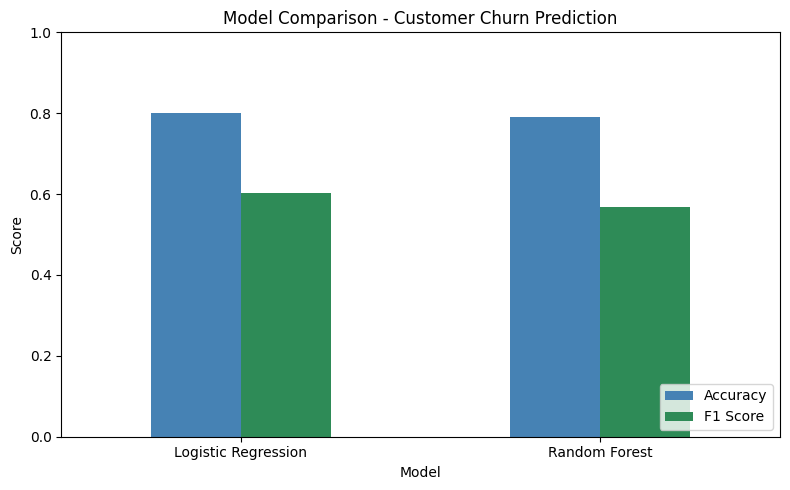

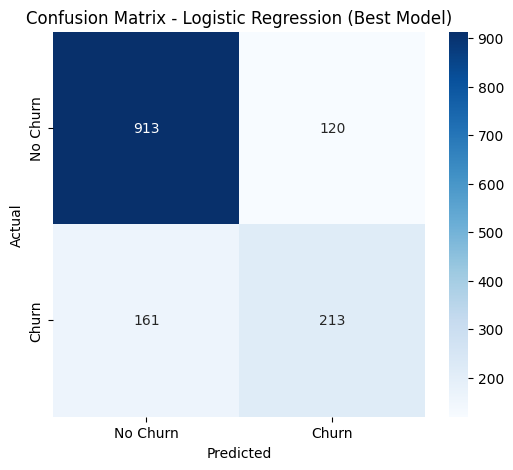


✅ Best model (Logistic Regression) pipeline exported as 'churn_pipeline.joblib'


In [1]:
# End-to-End ML Pipeline with Scikit-learn Pipeline API
# Customer Churn Prediction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Download Telco Customer Churn dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print(df.head())

# Data Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

# Target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("\nNumeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ===== Logistic Regression Pipeline =====
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_param_grid = {
    'classifier__C': [0.1, 1, 10]
}

lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=5, scoring='f1')
lr_grid.fit(X_train, y_train)

lr_pred = lr_grid.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(f"\n=== Logistic Regression ===")
print(f"Best Params: {lr_grid.best_params_}")
print(f"Accuracy: {lr_acc:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print(classification_report(y_test, lr_pred))

# ===== Random Forest Pipeline =====
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1')
rf_grid.fit(X_train, y_train)

rf_pred = rf_grid.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"\n=== Random Forest ===")
print(f"Best Params: {rf_grid.best_params_}")
print(f"Accuracy: {rf_acc:.4f}")
print(f"F1 Score: {rf_f1:.4f}")
print(classification_report(y_test, rf_pred))

# ===== Comparison =====
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_acc, rf_acc],
    'F1 Score': [lr_f1, rf_f1]
})
print("\n=== Model Comparison ===")
print(results)

# Plot comparison
results.set_index('Model').plot(kind='bar', figsize=(8,5), color=['steelblue', 'seagreen'])
plt.title('Model Comparison - Customer Churn Prediction')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Confusion matrix for best model
best_pred = rf_pred if rf_f1 > lr_f1 else lr_pred
best_name = "Random Forest" if rf_f1 > lr_f1 else "Logistic Regression"

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title(f'Confusion Matrix - {best_name} (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Export the best pipeline
best_pipeline = rf_grid.best_estimator_ if rf_f1 > lr_f1 else lr_grid.best_estimator_
joblib.dump(best_pipeline, 'churn_pipeline.joblib')
print(f"\n✅ Best model ({best_name}) pipeline exported as 'churn_pipeline.joblib'")